# Core Analysis Code
## Input
This file needs following file which is generated in another notebook for top X employers:
1. Top X database file containing columns: year, <i><b>"uniform"</i> employer name, prevailing & LCA wages & wage levels.

## Analysis
Three types of analysis are done:
1. Analysis1: Year & Employer
2. Analysis2: Year & Insights <i><b>['Descriptive_Statistics', 'Box', 'Scatter', 'Scatter_with_Slope', 'Histogram', 'Density', 'Cumulative', 'Bars_Wage_Level']</i> for all pre-selected top X employers
3. Analysis3: Insights & Employer. A particular insight for an employer for all years in the database.
    
## Ouput
Two types:
1. In Jupyter notebook
2. Stand-alone HTML file (takes time to generate)

In [2]:
import pandas as pd
import numpy as np
import collections
from scipy.stats import linregress

In [3]:
import panel as pn
import holoviews as hv
from holoviews import opts
import hvplot.pandas
# FuncTickFormatter has been removed from latest version of Bokeh, instead use formatters.CustomJSTickFormatter
# from bokeh.models import FuncTickFormatter, HoverTool 
from bokeh.models import formatters
from bokeh.models import HoverTool
from bokeh.resources import INLINE


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
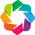

In [4]:
hv.extension('bokeh')

In [5]:
df_cdx5 = pd.read_csv('DataFrame_top30_Employers_Final.csv', low_memory=False)
df_cdx5['YEAR'] = df_cdx5['YEAR'].astype(str)

In [6]:
df_cdx5.count().apply(lambda x: f'{x:,}')

YEAR               1,223,025
EMPLOYER_NAME      1,223,025
PREVAILING_WAGE    1,223,025
LCA_WAGE           1,223,025
PW_WAGE_LEVEL        598,084
dtype: object

## Important Note:
1. <font size=2> For all the analysis, 'PREVAILING_WAGE' range is set between (20000, 200000) & LCA_WAGE range is set between (25000, 400000). 
2. <font size=2> This is to filter out unrealistic wages. This general range was decided after doing analysis of wages from 2008, 2010-2019, lot of time was spent on this.
3. <font size=2> These ranges can be changed in the code for specific year of interest, if required.

In [7]:
df_cdx5_filtered = df_cdx5[(df_cdx5['PREVAILING_WAGE'].between(20000, 200000)) & (df_cdx5['LCA_WAGE'].between(25000, 400000))]

In [8]:
df_cdx5_filtered.count().apply(lambda x: f'{x:,}')

YEAR               1,140,616
EMPLOYER_NAME      1,140,616
PREVAILING_WAGE    1,140,616
LCA_WAGE           1,140,616
PW_WAGE_LEVEL        587,377
dtype: object

In [9]:
year_list_wl = ['2015', '2017', '2018', '2019']

# for Analysis 2 & 3 wage levels
df_t = df_cdx5_filtered[df_cdx5_filtered['YEAR'].isin(year_list_wl)][['YEAR', 'EMPLOYER_NAME', 'PW_WAGE_LEVEL']]

# for Analysis 2, 
emp_num = [i for i in zip([i for i in range(0, len(df_t['EMPLOYER_NAME'].unique()))], df_t['EMPLOYER_NAME'].unique())]

# for Analysis 3
num_year = [i for i in zip([i for i in range(0, len(year_list_wl))], year_list_wl)]

In [10]:
# HoverTools
hover_LCA_hist = HoverTool(tooltips=[('LCA_WAGE', '$'+'@LCA_WAGE{0,}'), ('Count', '@LCA_WAGE_count')])
hover_PW_hist = HoverTool(tooltips=[('PREVAILING_WAGE', '$'+'@PREVAILING_WAGE{0,}'), ('Count', '@PREVAILING_WAGE_count')])
hover_LCA_cum = HoverTool(tooltips=[('LCA_WAGE', '$'+'@LCA_WAGE{0,}'), ('Frequency', '@LCA_WAGE_frequency')])
hover_PW_cum = HoverTool(tooltips=[('PREVAILING_WAGE', '$'+'@PREVAILING_WAGE{0,}'), ('Frequency', '@PREVAILING_WAGE_frequency')])
hover_scatter = HoverTool(tooltips=[('LCA_WAGE', '$'+'@LCA_WAGE{0,}'), ('PREVAILING_WAGE', '$'+'@PREVAILING_WAGE{0,}')])
hover_box = HoverTool(tooltips=[('WAGE_TYPE', '@Variable'), ('WAGE_VALUE', '$'+'@value{0,}')])
hover_LCA_level = HoverTool(tooltips=[('Level', '@Level'), ('Counts', '@Counts{0,}'), ('Percentage', '@Percentage')])
hover_wagetrend = HoverTool(tooltips=[('Year', '@year'), ('value', '$'+'@value{0,}'), ('Type', '@Variable')])

In [11]:
def SetPlotSize():
    return 400, 600

## Analysis 1
### Year & Employer

In [ ]:
# Yearwise analysis for an employer from list, here top 25/30 - YEAR & EMPLOYER NAME

plot_height_ye, plot_width_ye = SetPlotSize()

# Widget for Year
year_widget1 = pn.widgets.Select(options=['2008']+[i for i in range(2010, 2020)], 
                                 name='Year: ', 
                                 width=100
                                )
# Widget for Employer Names
emp_wgt1 = pn.widgets.Select(options=df_cdx5['EMPLOYER_NAME'].unique().tolist(), 
                             name='Employer: ', 
                             width=300, 
                             disabled=False
                            )

# Can't use single variable, it gives RuntimeError: Models must be owned by only a single document, formatters.CustomJSTickFormatter(id='1001', ...) is already in a doc
tickformatter_1 = formatters.CustomJSTickFormatter(code=""" return ("$" + Math.floor(tick * 1e-3) + "K")""")

# When widgets year_wgt or emp_wgt changes, function Analysis1 is called
# Parameters year_wgt & emp_wgt inside function carry the values
@pn.depends(year_widget1, emp_wgt1)
def Analysis1(year_widget1, emp_wgt1):
    
    df_ye = df_cdx5_filtered[(df_cdx5_filtered['YEAR'] == str(year_widget1)) & 
                             (df_cdx5_filtered['EMPLOYER_NAME'] == emp_wgt1)
                            ]
    if not df_ye.empty:
        # Descriptive Statistics for both PREVAILING & LCA Wages
        df_descriptive = pd.DataFrame(df_ye[['PREVAILING_WAGE', 'LCA_WAGE']].describe())
        # Create top level single label denoting Employer Name for both the descriptive statistcs columns
        # df_descriptive.columns= pd.MultiIndex.from_product([[emp_wgt1], df_descriptive.columns])
        datax5_descriptive = hv.Table(data=df_descriptive.round(2).reset_index().rename(columns={'index': 'DESCRIPTIVE STATISTICS'})
                                     ).opts(editable=False, 
                                            fit_columns=True,
                                            index_position=None,
                                            width=500,
                                           )
        
        # box
        datax5_box = df_ye.hvplot(kind='box', 
                                  y=['PREVAILING_WAGE', 'LCA_WAGE'], 
                                  yformatter=tickformatter_1, 
                                  height=plot_height_ye, width=plot_width_ye, 
                                  tools=[hover_box], color='mediumorchid',
                                  box_hover_color='yellow', box_line_color='white',
                                  whisker_color='brown', outlier_color='red', 
                                  title='Box Plot', fontsize={'title': 10}, 
                                 ).opts(toolbar=None, bgcolor='lemonchiffon')
        
        # Scatter PREVAILING vs LCA
        datax5 = df_ye.hvplot(kind='scatter', 
                              x='PREVAILING_WAGE', y='LCA_WAGE',
                              xformatter=tickformatter_1, yformatter=tickformatter_1,                     
                              height=plot_height_ye, width=plot_width_ye, 
                              tools=[hover_scatter], size=5, color='mediumorchid',
                              xlabel='PREVAILING_WAGE', ylabel='LCA_WAGE',
                              # fill_color='mediumorchid', color='mediumorchid', line_color='mediumorchid',
                              fontsize={'title': 10}, title='Scatter Plot'
                             ).opts(toolbar=None, bgcolor='lemonchiffon')
        # Slope from Scatter PREVAILING vs LCA
        datax5_slope = hv.Slope.from_scatter(datax5).opts(color='orange', line_width=3) * datax5
        # reject the null hypothesis that slope is zero, because p is less than alpha 0.05
        slope, intercept, rvalue, pvalue, stderr=linregress(df_ye['PREVAILING_WAGE'], df_ye['LCA_WAGE'])
        datax5_slope.label = 'slope: {:0.2f}, '.format(slope) + 'intercept: {:0.2f}, '.format(intercept) + \
                             'rvalue: {:0.2f}, '.format(rvalue) + 'pvalue: {:0.2f}, '.format(pvalue) + \
                             'stderr: {:0.2f}'.format(stderr)
        datax5_slope.opts(fontsize={'title': 9}, title=datax5_slope.label, toolbar=None, bgcolor='lemonchiffon')

        # Density PREVAILING WAGE
        datax5_kde_pw = df_ye.hvplot(kind='density',  
                                     y='PREVAILING_WAGE', 
                                     xformatter=tickformatter_1, 
                                     height=plot_height_ye, width=plot_width_ye, 
                                     color='mediumorchid', hover_color='yellow',
                                     hover_line_color='mediumorchid',
                                     title='Density Plot Prevailing Wage', fontsize={'title': 10},
                                    ).opts(toolbar=None, bgcolor='lemonchiffon')

        # Density LCA WAGE
        datax5_kde_lca = df_ye.hvplot(kind='density', 
                                      y='LCA_WAGE', 
                                      xformatter=tickformatter_1,  
                                      height=plot_height_ye, width=plot_width_ye, 
                                      color='mediumorchid', hover_color='yellow',
                                      hover_line_color='mediumorchid',
                                      title='Density Plot LCA Wage', fontsize={'title': 10},
                                     ).opts(toolbar=None, bgcolor='lemonchiffon')

        # Histogram PREVAILING WAGE
        datax5_hist_pw = df_ye.hvplot(kind='hist', 
                                      y='PREVAILING_WAGE',  
                                      xformatter=tickformatter_1, 
                                      height=plot_height_ye, width=plot_width_ye,
                                      color='mediumorchid', line_color='white',
                                      hover_color='yellow', hover_line_color='black',
                                      bins=30, 
                                      tools=[hover_PW_hist],
                                      title='Histogram Prevailing Wage', fontsize={'title': 10},
                                     ).opts(toolbar=None, bgcolor='lemonchiffon')

        # Histogram LCA WAGE
        datax5_hist_lca = df_ye.hvplot(kind='hist', 
                                       y='LCA_WAGE', 
                                       xformatter=tickformatter_1,
                                       height=plot_height_ye, width=plot_width_ye, 
                                       color='mediumorchid', line_color='white',
                                       hover_color='yellow', hover_line_color='black',
                                       bins=30, 
                                       tools=[hover_LCA_hist],
                                       title='Histogram LCA Wage', fontsize={'title': 10},
                                      )

        # Cumulative PREVAILING WAGE
        datax5_hist_pw_c = df_ye.hvplot(kind='hist',
                                        y='PREVAILING_WAGE',
                                        xformatter=tickformatter_1, 
                                        height=plot_height_ye, width=plot_width_ye, 
                                        color='mediumorchid', line_color='white',
                                        hover_color='yellow', hover_line_color='mediumorchid',
                                        bins=30, 
                                        cumulative=True, normed=True,
                                        tools=[hover_PW_cum],
                                        title='Cumulative Prevailing Wage', fontsize={'title': 10},
                                       ).opts(toolbar=None, bgcolor='lemonchiffon')

        # Cumulative LCA WAGE
        datax5_hist_lca_c = df_ye.hvplot(kind='hist', 
                                         y='LCA_WAGE', 
                                         xformatter=tickformatter_1, 
                                         height=plot_height_ye, width=plot_width_ye, 
                                         color='mediumorchid', line_color='white',
                                         hover_color='yellow', hover_line_color='mediumorchid',
                                         bins=30, 
                                         cumulative=True, normed=True,
                                         tools=[hover_LCA_cum],
                                         title='Cumulative LCA Wage', fontsize={'title': 10},
                                        ).opts(toolbar=None, bgcolor='lemonchiffon')

        # Create Layout for above plots
        layout1 = hv.Layout(datax5_descriptive + 
                            datax5_box + datax5 + 
                            datax5_slope + datax5_kde_pw + 
                            datax5_kde_lca + datax5_hist_pw + 
                            datax5_hist_lca + datax5_hist_pw_c + 
                            datax5_hist_lca_c  
                           ).cols(2)

        # WAGE LEVEl is not available for all years... so check for it.. 
        if((str(year_widget1) == '2015') or (str(year_widget1) == '2017') or 
           (str(year_widget1) == '2018') or (str(year_widget1) == '2019')):
            # WAGE LEVEL
            # For particular year & employer, count unique wage levels 
            # (items(): list of "tuples" containing "unique wage level & its counts")
            # & convert it into dataframe
            df_x5_level = pd.DataFrame(collections.Counter(df_ye[(df_ye['YEAR'] == str(year_widget1)) &
                                                                 (df_ye['EMPLOYER_NAME'] == emp_wgt1)
                                                                ]['PW_WAGE_LEVEL']
                                                          ).items(), 
                                       columns=['Level', 'Counts']
                                      ).sort_values('Level')
            # Add a column for Percentage in hover for each bar 
            df_x5_level['Percentage'] = (df_x5_level.Counts/df_x5_level.Counts.sum() * 100
                                        ).round(2).astype(str) + '%'
            # hover_all is an option to display a column from dataframe in the hover
            layout2 = hv.Layout(df_x5_level.hvplot(kind='bar', 
                                                   x='Level', y='Counts', 
                                                   height=plot_height_ye, width=plot_width_ye, 
                                                   fill_color='mediumorchid',
                                                   hover_color='yellow', hover_line_color='mediumorchid',
                                                   tools=[hover_LCA_level], hover_cols='all', 
                                                   title=emp_wgt1 + ': ' + 'WAGE_LEVEL'                        
                                                  ).opts(fontsize={'title': 8},
                                                         toolbar=None,
                                                         bgcolor='lemonchiffon'
                                                        ) 
                                + 
                                hv.Div('Total Counts: {}'.format(df_x5_level['Counts'].sum()))  # Total counts
                                )
            # If WAGE LEVEL is available, add WAGE LEVEL plot to layout1.
            return (layout1 + layout2).opts(merge_tools=True, toolbar=None).cols(2)
        else:
            # If WAGE LEVEL is not available, display layout1 only
            return layout1.opts(merge_tools=True, toolbar=None)
    else:
        return pn.pane.Markdown('<b>Data for year: ' + str(year_widget1) + ' is not available. <br> Select another year. <br> <i> Note: For some employers data is available from 2014 onwards.')

# Set everything in an order for GUI, Analysis1 is called whenever year_wgt, emp_wgt changes
# Analysis1 returns layout for plots, it should.. 

title_html = pn.pane.Markdown('# Year-Wise Analysis by Employer (Top 30)')
pn.Column(title_html, pn.WidgetBox(pn.Row(year_widget1, emp_wgt1)), pn.Column(Analysis1)).save('top29IndividualAnalysis.html', resources=INLINE, embed=True)


## Analysis 2
### Year & Insights 
- Insights <b><i>'Descriptive_Statistics', 'Box', 'Scatter', 'Scatter_with_Slope', 'Histogram', 'Density', 'Cumulative' & 'Bars_Wage_Level'</b> for all pre-selected top X employers

In [ ]:
# Year & Insights for all top 25/30 employers, there is no choice to select an employer here - YEAR & INSIGHTS

plot_height_yi, plot_width_yi = SetPlotSize()

insights = ['Descriptive_Statistics', 'Box', 'Scatter', 'Scatter_with_Slope', 'Histogram', 'Density', 'Cumulative', 'Bars_Wage_Level']

# height=300, width=500,
year_widget2 = pn.widgets.Select(options=['2008']+[i for i in range(2010, 2020)], name='Year: ', 
                                 width=100
                                )

insight_widget2 = pn.widgets.Select(options=insights, name='Insights: ', 
                                    width=200
                                   )

tickformatter_2 = formatters.CustomJSTickFormatter(code=""" return ("$" + Math.floor(tick * 1e-3) + "K")""")

@pn.depends(year_widget2, insight_widget2)
def Analysis2(year_widget2, insight_widget2):
    df_x5_sy = df_cdx5_filtered[(df_cdx5_filtered['YEAR'] == str(year_widget2))]

############################################# Scatter ##################################
    if insight_widget2 == 'Scatter':
        hv_scatter = [df_x5_sy[df_x5_sy['EMPLOYER_NAME'] == i].hvplot.scatter(x='PREVAILING_WAGE', y='LCA_WAGE', 
                                                                              xformatter=tickformatter_2,  yformatter=tickformatter_2,
                                                                              tools=[hover_scatter], color='mediumorchid', size=5,
                                                                              height=plot_height_yi, width=plot_width_yi,
                                                                              xlabel='PREVAILING_WAGE', ylabel='LCA_WAGE',
                                                                              subplots=True, shared_axes=False, title=i,
                                                                             ).opts(legend_position='top', 
                                                                                    show_legend=True, 
                                                                                    fontsize={'title': 10},
                                                                                    bgcolor='lemonchiffon'
                                                                                   ) for i in list(df_x5_sy['EMPLOYER_NAME'].unique())
                     ]
        return hv.Layout(hv_scatter).opts(toolbar=None).cols(3)
    elif insight_widget2 == 'Histogram':
###################################### histogram #########################################
        hv_hist_pw = [df_x5_sy[df_x5_sy['EMPLOYER_NAME'] == i].hvplot.hist(y='PREVAILING_WAGE', ylabel='Counts',
                                                                           tools=[hover_PW_hist], xformatter=tickformatter_2,
                                                                           height=plot_height_yi, width=plot_width_yi, 
                                                                           color='mediumorchid', line_color='white',
                                                                           hover_color='yellow', 
                                                                           hover_line_color='mediumorchid',
                                                                           shared_axes=False, title=i, 
                                                                           fontsize={'title': 10}, bins =30,
                                                                           #   cumulative=True, normed=True,
                                                                          ).opts(bgcolor='lemonchiffon') for i in df_x5_sy['EMPLOYER_NAME'].unique()
                     ]
        hv_hist_lca = [df_x5_sy[df_x5_sy['EMPLOYER_NAME'] == i].hvplot.hist(y='LCA_WAGE', ylabel='Counts',
                                                                            tools=[hover_LCA_hist], xformatter=tickformatter_2,
                                                                            height=plot_height_yi, width=plot_width_yi, 
                                                                            color='mediumorchid', line_color='white',
                                                                            hover_color='yellow', 
                                                                            hover_line_color='mediumorchid',
                                                                            shared_axes=False,
                                                                            title=i, fontsize={'title': 10}, bins=30,
                                                                            #   cumulative=True, normed=True,
                                                                           ).opts(bgcolor='lemonchiffon') for i in df_x5_sy['EMPLOYER_NAME'].unique()
                      ]
        return hv.Layout([hv_hist_pw[i] + hv_hist_lca[i] for i in range(0, len(hv_hist_pw))]).opts(toolbar=None).cols(4) 
    elif insight_widget2 == 'Cumulative':
###################################### Cumulative #########################################
        hv_cumulative_pw = [df_x5_sy[df_x5_sy['EMPLOYER_NAME'] == i].hvplot.hist(y='PREVAILING_WAGE', ylabel='Frequency',
                                                                                 tools=[hover_PW_cum], xformatter=tickformatter_2,
                                                                                 height=plot_height_yi, width=plot_width_yi, 
                                                                                 color='mediumorchid', line_color='white',
                                                                                 hover_color='yellow', 
                                                                                 hover_line_color='mediumorchid',
                                                                                 shared_axes=False,
                                                                                 title=i, fontsize={'title': 10}, bins=30,
                                                                                 cumulative=True, normed=True,
                                                                                ).opts(bgcolor='lemonchiffon') for i in df_x5_sy['EMPLOYER_NAME'].unique()
                           ]
        hv_cumulative_lca = [df_x5_sy[df_x5_sy['EMPLOYER_NAME'] == i].hvplot.hist(y='LCA_WAGE', ylabel='Frequency',
                                                                                  tools=[hover_LCA_cum], xformatter=tickformatter_2,
                                                                                  height=plot_height_yi, width=plot_width_yi, 
                                                                                  color='mediumorchid', line_color='white',
                                                                                  hover_color='yellow', 
                                                                                  hover_line_color='mediumorchid',
                                                                                  shared_axes=False,
                                                                                  title=i, fontsize={'title': 10}, bins=30,
                                                                                  cumulative=True, normed=True,
                                                                                 ).opts(bgcolor='lemonchiffon') for i in df_x5_sy['EMPLOYER_NAME'].unique()
                            ]
        return hv.Layout([hv_cumulative_pw[i] + hv_cumulative_lca[i] for i in range(0, len(hv_cumulative_pw))]).opts(toolbar=None).cols(4)
    elif insight_widget2 == 'Box':
###################################### box #########################################
        hv_box = [df_x5_sy[df_x5_sy['EMPLOYER_NAME'] == i].hvplot.box(y=['PREVAILING_WAGE', 'LCA_WAGE'], 
                                                                      yformatter=tickformatter_2, tools= [hover_box],
                                                                      height=plot_height_yi, width=plot_width_yi, 
                                                                      color='mediumorchid',
                                                                      box_hover_color='yellow', whisker_color='brown', 
                                                                      outlier_color='red', box_line_color='white',
                                                                      shared_axes=False,
                                                                      title=i, fontsize={'title': 10}
                                                                     ).opts(bgcolor='lemonchiffon') for i in df_x5_sy['EMPLOYER_NAME'].unique()
                 ]
        return hv.Layout(hv_box).opts(toolbar=None).cols(3)
    elif insight_widget2 == 'Density':
###################################### density #########################################
        hv_density_pw = [df_x5_sy[df_x5_sy['EMPLOYER_NAME'] == i].hvplot.density(y='PREVAILING_WAGE', xformatter=tickformatter_2,
                                                                                 height=plot_height_yi, width=plot_width_yi, 
                                                                                 color='mediumorchid', hover_color='yellow',
                                                                                 hover_line_color='mediumorchid',
                                                                                 shared_axes=False,
                                                                                 title=i,
                                                                                 fontsize={'title': 10},
                                                                                ).opts(bgcolor='lemonchiffon') for i in df_x5_sy['EMPLOYER_NAME'].unique()
                        ]
        hv_density_lca = [df_x5_sy[df_x5_sy['EMPLOYER_NAME'] == i].hvplot.density(y='LCA_WAGE', xformatter=tickformatter_2,
                                                                                  height=plot_height_yi, width=plot_width_yi, 
                                                                                  color='mediumorchid', hover_color='yellow',
                                                                                  hover_line_color='mediumorchid',
                                                                                  shared_axes=False,
                                                                                  title=i,
                                                                                  fontsize={'title': 10},
                                                                                 ).opts(bgcolor='lemonchiffon') for i in df_x5_sy['EMPLOYER_NAME'].unique()
                         ]
        return hv.Layout([hv_density_pw[i] + hv_density_lca[i] for i in range(0, len(hv_density_pw))]).opts(toolbar=None).cols(4)
    elif insight_widget2 == 'Scatter_with_Slope':
############################################# Scatter Slope ##################################
        hv_scatter = [df_x5_sy[df_x5_sy['EMPLOYER_NAME'] == i].hvplot.scatter(x='PREVAILING_WAGE', y='LCA_WAGE', 
                                                                              xformatter=tickformatter_2,  yformatter=tickformatter_2,
                                                                              tools=[hover_scatter], color='mediumorchid', size=5,
                                                                              height=plot_height_yi, width=plot_width_yi, 
                                                                              xlabel='PREVAILING_WAGE', ylabel='LCA_WAGE',
                                                                              subplots=True, shared_axes=False, title=i, 
                                                                             ).opts(legend_position='top', 
                                                                                    show_legend=True, 
                                                                                    fontsize={'title': 10},
                                                                                    bgcolor='lemonchiffon'
                                                                                   ) for i in list(df_x5_sy['EMPLOYER_NAME'].unique())
                     ]
        hv_slope_scatter = [hv.Slope.from_scatter(hv_scatter[i]).opts(color ='orange', line_width=3) * hv_scatter[i] for i in range(0, len(hv_scatter))]

        for i in range(0, len(hv_slope_scatter)):
            # reject the null hypothesis that slope is zero, because p is less than alpha 0.05
            slope, intercept, rvalue, pvalue, stderr=linregress(hv_scatter[i].data['PREVAILING_WAGE'], hv_scatter[i].data['LCA_WAGE'])
            hv_slope_scatter[i] = hv_slope_scatter[i] + hv.Div(pd.DataFrame([('slope', slope), ('intercept', intercept), 
                                                                             ('rvalue', rvalue), ('pvalue', pvalue), 
                                                                             ('stderr',stderr)
                                                                            ], 
                                                                            columns=['Stats', 'Values']
                                                                           ).round(2).to_html()
                                                              )
        return hv.Layout(hv_slope_scatter).opts(merge_tools=True, shared_axes=False).opts(toolbar=None).cols(4)
    elif insight_widget2 == 'Descriptive_Statistics':
############################################# Descriptive Statistics ##################################
        hvs_table = [pd.DataFrame(df_x5_sy[df_x5_sy['EMPLOYER_NAME'] == i][['PREVAILING_WAGE', 'LCA_WAGE']].describe(percentiles=[0.25, 0.5, 0.75, 0.9])) 
                     for i in list(df_x5_sy['EMPLOYER_NAME'].unique())
                    ]
        # Run below MutliIndex code for only one time, second run gives 'NotImplementedError: isna is not defined for MultiIndex', because you are adding the level again without making any changes..
        # To remove the error run above line that generates 'hvs_table' and then run this cell. The flow should be maintained.
        for i, j in zip(range(0, len(hvs_table)),list(df_x5_sy['EMPLOYER_NAME'].unique())):
            hvs_table[i].columns = pd.MultiIndex.from_product([[j], hvs_table[i].columns])

        dstats = pd.concat(hvs_table, axis=1)
        # raw dstats.T output overwrites in the output section of notebook, so convert it into html
        # you can round the cell values to limit decimal points before converting to HTML
        # both return works..
        # return(dstats.T.round(2).to_html())
        return hv.Table(dstats.T.round(2).reset_index().rename(columns={'level_0': 'Employer', 'level_1': 'Wages'})
                       ).opts(editable=False, 
                              fit_columns=True, 
                              index_position=None,
                              width=1200, height=1500, 
                             )
    elif insight_widget2 == 'Bars_Wage_Level':
    ########################################## level ###############################
        if((str(year_widget2) == '2015') or (str(year_widget2) == '2017') or 
           (str(year_widget2) == '2018') or (str(year_widget2) == '2019')):
            df_t_level = [pd.DataFrame(collections.Counter(df_t[(df_t['YEAR'] == str(year_widget2)) &
                                                                (df_t['EMPLOYER_NAME'] == i[1])
                                                               ]['PW_WAGE_LEVEL']
                                                           ).items(), 
                                       columns=['Level', 'Counts'],
                                      ).sort_values('Level')
                          for i in emp_num
                         ]
            for i in emp_num:
                df_t_level[i[0]]['Percentage']=(df_t_level[i[0]].Counts/df_t_level[i[0]].Counts.sum() * 100
                                                 ).round(2).astype(str) + '%'
            level_plot = [df_t_level[i[0]].hvplot.bar(x='Level', y='Counts', title=i[1], 
                                                      xlabel='Wage Level', shared_axes=False, 
                                                      height=plot_height_yi, width=plot_width_yi,
                                                      hover_cols=['Level', 'Counts', 'Percentage'],
                                                      fontsize={'title': 8}, fill_color='mediumorchid',
                                                      hover_color='yellow', hover_line_color='mediumorchid',
                                                     ).opts(bgcolor='lemonchiffon') for i in emp_num
                         ]
            return hv.Layout(level_plot).cols(3)
        else:
            return hv.Div('Wage level not available for: ' + str(year_widget2))
    else:
        return hv.Div('Options not valid')

title_html = pn.pane.Markdown('# Comparision Analysis By Employer')
pn.Column(title_html, pn.WidgetBox(pn.Row(year_widget2, insight_widget2)), Analysis2).save('top29Analysis.html', resources=INLINE, embed=True, title='TOP 25 H1B Analysis')


## Analysis 3
### Insights & Employer
- A particular insight <b><i>'Descriptive_Statistics', 'Box', 'Scatter', 'Scatter_with_Slope', 'Histogram', 'Density', 'Cumulative' & 'Bars_Wage_Level', 'Wage_Trends'</b> for an employer for all years in the database.

In [15]:
# Insights for all top 25/30 employers, there is a choice to select an employer here - INSIGHTS & EMPLOYER NAME

plot_height_ie, plot_width_ie = SetPlotSize()

insights = ['Descriptive_Statistics', 'Box', 'Scatter', 'Scatter_with_Slope', 'Histogram', 'Density', 'Cumulative', 'Bars_Wage_Level', 'Wage_Trends']

insight_widget3 = pn.widgets.Select(options=insights, name='Insights: ', 
                                width=200
                               )

# Widget for Employer Names
emp_wgt3 = pn.widgets.Select(options=list(df_cdx5['EMPLOYER_NAME'].unique()), 
                            name='Employer: ', width=300, 
                            disabled=False
                           )

tickformatter_3 = formatters.CustomJSTickFormatter(code=""" return ("$" + Math.floor(tick * 1e-3) + "K")""")

@pn.depends(insight_widget3, emp_wgt3)
def Analysis3(insight_widget3, emp_wgt3):
    df_x5_emp = df_cdx5_filtered[df_cdx5_filtered['EMPLOYER_NAME'] == emp_wgt3]
    year_list = df_x5_emp['YEAR'].unique()
    
    if insight_widget3 == 'Scatter':
        ######################################### scatter ################################
        hv_scatter = [df_x5_emp[df_x5_emp['YEAR'] == i].hvplot.scatter(x='PREVAILING_WAGE', y='LCA_WAGE', 
                                                                       xformatter=tickformatter_3,  yformatter=tickformatter_3, 
                                                                       tools=[hover_scatter],
                                                                       height=plot_height_ie, width=plot_width_ie,
                                                                       color='mediumorchid', size=5,
                                                                       xlabel='PREVAILING_WAGE', ylabel='LCA_WAGE',                                                                       
                                                                       subplots=True, shared_axes=False, title=emp_wgt3 + ': ' + i,
                                                                      ).opts(legend_position='top', 
                                                                             show_legend=True, 
                                                                             fontsize={'title': 8},
                                                                             bgcolor='lemonchiffon'
                                                                            ) for i in year_list
                     ]
        return hv.Layout(hv_scatter).opts(toolbar=None).cols(3)
    elif insight_widget3 == 'Histogram':
        ############################## histogram #########################################
        hv_hist_pw = [df_x5_emp[df_x5_emp['YEAR'] == i].hvplot.hist(y='PREVAILING_WAGE', ylabel='Counts',
                                                                    xformatter=tickformatter_3, tools=[hover_PW_hist], 
                                                                    height=plot_height_ie, width=plot_width_ie, 
                                                                    color='mediumorchid', hover_color='yellow',
                                                                    line_color='white', hover_line_color='mediumorchid',
                                                                    shared_axes=False,
                                                                    title=emp_wgt3 + ': ' + i, 
                                                                    fontsize={'title': 8}, bins=30,
                                                                       #   cumulative=True, normed=True,
                                                                   ).opts(bgcolor='lemonchiffon'
                                                                         ) for i in year_list
                     ]
        hv_hist_lca = [df_x5_emp[df_x5_emp['YEAR'] == i].hvplot.hist(y='LCA_WAGE', ylabel='Counts',
                                                                     xformatter=tickformatter_3, tools=[hover_LCA_hist], 
                                                                     height=plot_height_ie, width=plot_width_ie, 
                                                                     color='mediumorchid', hover_color='yellow',
                                                                     line_color='white', hover_line_color='mediumorchid',
                                                                     shared_axes=False,
                                                                     title=emp_wgt3 + ': ' + i, 
                                                                     fontsize={'title': 8}, bins=30,                                                            
                                                                       #   cumulative=True, normed=True,
                                                                    ).opts(bgcolor='lemonchiffon'
                                                                          ) for i in year_list
                      ]
        return hv.Layout([hv_hist_pw[i] + hv_hist_lca[i] for i in range(0, len(hv_hist_pw))]).opts(toolbar=None).cols(4)
    elif insight_widget3 == 'Cumulative':
        ############################## Cumulative #########################################
        hv_cumulative_pw = [df_x5_emp[df_x5_emp['YEAR'] == i].hvplot.hist(y='PREVAILING_WAGE', ylabel='Frequency',
                                                                          tools=[hover_PW_cum], xformatter=tickformatter_3,
                                                                          height=plot_height_ie, width=plot_width_ie, 
                                                                          color='mediumorchid', hover_color='yellow',
                                                                          line_color='white', hover_line_color='mediumorchid',
                                                                          shared_axes=False,
                                                                          title=emp_wgt3 + ': ' + i, 
                                                                          fontsize={'title': 8}, bins=30,
                                                                          cumulative=True, normed=True,
                                                                          ).opts(bgcolor='lemonchiffon'
                                                                                ) for i in year_list
                           ]
        hv_cumulative_lca = [df_x5_emp[df_x5_emp['YEAR'] == i].hvplot.hist(y='LCA_WAGE', ylabel='Frequency',
                                                                           tools=[hover_LCA_cum], xformatter=tickformatter_3,
                                                                           height=plot_height_ie, width=plot_width_ie, 
                                                                           color='mediumorchid', hover_color='yellow',
                                                                           line_color='white', hover_line_color='mediumorchid',
                                                                           shared_axes=False,
                                                                           title=emp_wgt3 + ': ' + i, 
                                                                           fontsize={'title': 8}, bins=30,
                                                                           cumulative=True, normed=True,
                                                                          ).opts(bgcolor='lemonchiffon'
                                                                                ) for i in year_list
                            ]
        return hv.Layout([hv_cumulative_pw[i] + hv_cumulative_lca[i] for i in range(0, len(hv_cumulative_pw))]).opts(toolbar=None).cols(4)
    elif insight_widget3 == 'Box':
        ############################## box ###############################################
        hv_box = [df_x5_emp[df_x5_emp['YEAR'] == i].hvplot.box(y=['PREVAILING_WAGE', 'LCA_WAGE'], 
                                                               yformatter=tickformatter_3, tools= [hover_box],
                                                               height=plot_height_ie, width=plot_width_ie, color='mediumorchid',
                                                               box_hover_color='yellow', whisker_color='brown', 
                                                               outlier_color='red', box_line_color='white',
                                                               shared_axes=False, xlabel='Wages',
                                                               title=emp_wgt3 + ': ' + i, fontsize={'title': 8},
                                                              ).opts(bgcolor='lemonchiffon',
                                                                    ) for i in year_list
                ]
        return hv.Layout(hv_box).opts(opts.Layout(toolbar=None)).cols(3)
    elif insight_widget3 == 'Density':
        ############################## density ###########################################
        hv_density_pw = [df_x5_emp[df_x5_emp['YEAR'] == i].hvplot.density(y='PREVAILING_WAGE', xformatter=tickformatter_3,
                                                                          height=plot_height_ie, width=plot_width_ie, 
                                                                          color='mediumorchid', hover_color='yellow',
                                                                          hover_line_color='mediumorchid',
                                                                          shared_axes=False, 
                                                                          title=emp_wgt3 + ': ' + i,
                                                                          fontsize={'title': 8},
                                                                         ).opts(bgcolor='lemonchiffon'
                                                                               ) for i in year_list
                        ]
        hv_density_lca = [df_x5_emp[df_x5_emp['YEAR'] == i].hvplot.density(y='LCA_WAGE', xformatter=tickformatter_3,
                                                                           height=plot_height_ie, width=plot_width_ie, 
                                                                           color='mediumorchid', hover_color='yellow',
                                                                           hover_line_color='mediumorchid',
                                                                           shared_axes=False,
                                                                           title=emp_wgt3 + ': ' + i,
                                                                           fontsize={'title': 8},
                                                                          ).opts(bgcolor='lemonchiffon'
                                                                                ) for i in year_list
                         ]
        return hv.Layout([hv_density_pw[i] + hv_density_lca[i] for i in range(0, len(hv_density_pw))]
                        ).opts(toolbar=None).cols(4)
    elif insight_widget3 == 'Scatter_with_Slope':
        ##################################### Scatter Slope ##############################
        hv_scatter = [df_x5_emp[df_x5_emp['YEAR'] == i].hvplot.scatter(x='PREVAILING_WAGE', y='LCA_WAGE', 
                                                                       xformatter=tickformatter_3,  yformatter=tickformatter_3,
                                                                       tools=[hover_scatter],
                                                                       height=plot_height_ie, width=plot_width_ie, 
                                                                       xlabel='PREVAILING_WAGE', ylabel='LCA_WAGE',
                                                                       subplots=True, shared_axes=False, title=emp_wgt3 + ': ' + i,
                                                                      ).opts(legend_position='top', 
                                                                             show_legend=True, 
                                                                             fontsize={'title': 8}, 
                                                                             fill_color= 'mediumorchid', line_color='white',
                                                                             bgcolor='lemonchiffon'
                                                                            ) for i in year_list
                     ]
        hv_slope = []

        for i in range(0, len(hv_scatter)):
        # reject the null hypothesis that slope is zero, because p is less than alpha 0.05
            slope, intercept, rvalue, pvalue, stderr=linregress(hv_scatter[i].data['PREVAILING_WAGE'], hv_scatter[i].data['LCA_WAGE'])
            hv_slope_scatter = hv.Slope(slope, intercept).opts(line_color='orange') * hv_scatter[i]
            hv_slope_scatter = hv_slope_scatter + hv.Div(pd.DataFrame([('slope', slope), ('intercept', intercept), 
                                                                       ('rvalue', rvalue), ('pvalue', pvalue), ('stderr',stderr)
                                                                      ], 
                                                                      columns=['Stats', 'Values']
                                                                     ).round(2).to_html()
                                                        )
            hv_slope.append(hv_slope_scatter)
        return hv.Layout(hv_slope).opts(merge_tools=True, shared_axes=False, toolbar=None).cols(4)
    elif insight_widget3 == 'Descriptive_Statistics':
        ##################################### Descriptive Statistics #####################
        hvs_table = [df_x5_emp[df_x5_emp['YEAR'] == i][['PREVAILING_WAGE', 'LCA_WAGE']].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).T for i in year_list]
        dstats_row = pd.concat([hvs_table[i] for i in range(0, len(hvs_table))], axis=0).reset_index().rename(columns={'index': 'wages'})
        dstats_row.insert(0, 'year', np.concatenate([(i, i) for i in year_list]))
        return hv.Table(dstats_row.round(2)).opts(editable=False,
                                                  fit_columns=True,
                                                  index_position=None,
                                                  width=1200, height=600, 
                                                 )
    elif insight_widget3 == 'Bars_Wage_Level':
        ##################################### Wage level #################################
        df_t_level_emp = df_t[df_t['EMPLOYER_NAME'] == emp_wgt3]
        df_t_level = [pd.DataFrame(collections.Counter(df_t_level_emp[df_t_level_emp['YEAR'] == i]['PW_WAGE_LEVEL']
                                                       ).items(), 
                                   columns=['Level', 'Counts'],
                                  ).sort_values('Level')
                      for i in ['2015', '2017', '2018', '2019']
                     ]
        for i in num_year:
            df_t_level[i[0]]['Percentage'] = (df_t_level[i[0]].Counts/df_t_level[i[0]].Counts.sum() * 100
                                             ).round(2).astype(str) + '%'
        level_plot = [df_t_level[i[0]].hvplot.bar(x='Level', y='Counts', title=emp_wgt3 + ': ' + i[1], 
                                                  xlabel='Wage Level', shared_axes=False, 
                                                  height=plot_height_ie, width=plot_width_ie,
                                                  fill_color='mediumorchid',
                                                  hover_color='yellow', hover_line_color='mediumorchid',
                                                  hover_cols=['Level', 'Counts', 'Percentage'],
                                                  fontsize={'title': 8}
                                                 ).opts(bgcolor='lemonchiffon')
                      for i in num_year
                     ]
        return hv.Layout(level_plot).opts(toolbar=None).cols(3)
    elif insight_widget3 == 'Wage_Trends':
        ##################################### Wage Trends #################################
        hvs_table = [df_x5_emp[df_x5_emp['YEAR'] == i][['PREVAILING_WAGE', 'LCA_WAGE']].describe().T for i in year_list]
        
        dstats_row = pd.concat([hvs_table[i] for i in range(0, len(hvs_table))], axis=0).reset_index().rename(columns={'index': 'wages'})
        dstats_row.insert(0, 'year', np.concatenate([(i, i) for i in year_list]))
        
        df_lca_wt = dstats_row[dstats_row['wages'].str.contains('LCA_WAGE', case=False, regex=False)].filter(['year', 'wages', 'mean', '50%'])
        df_lca_wt.rename(columns={'mean': 'LCA_mean', '50%': 'LCA_median'}, inplace=True)
        
        df_pw_wt = dstats_row[dstats_row['wages'].str.contains('PREVAILING_WAGE', case=False, regex=False)].filter(['year', 'wages','mean', '50%'])
        df_pw_wt.rename(columns={'mean': 'PW_mean', '50%': 'PW_median'}, inplace=True)
        
        df_wage_trends = df_lca_wt.drop(columns='wages').merge(df_pw_wt.drop(columns='wages')).round()
        df_wage_trends = df_wage_trends.filter(['year', 'PW_mean', 'LCA_mean', 'PW_median', 'LCA_median'])
        
        wage_trend = df_wage_trends.hvplot.line(x='year', y=['PW_mean', 'LCA_mean', 'PW_median', 'LCA_median'],
                                                xlabel='Year', ylabel='Wage', height=500, width=900, 
                                                line_width=5, yformatter=tickformatter_3, line_color=['dodgerblue', 'blue', 'lime', 'orange'], 
                                                grid=True, tools=[hover_wagetrend]
                                               ).opts(bgcolor='lemonchiffon', 
                                                      legend_position='top_left', 
                                                      toolbar=None
                                                     )
        return (wage_trend + hv.Table(df_wage_trends)).opts(merge_tools=True, toolbar=None)
    else:
        return 0

title_html = pn.pane.Markdown('# Insights by Employer')
pn.Column(title_html, pn.WidgetBox(pn.Row(emp_wgt3, insight_widget3)), Analysis3).save('AnalysisEmpInsights.html', resources=INLINE, embed=True, title='H1B_Analysis')
